<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/66ml_final_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML FINAL EXAM

### Email:

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/insurance.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
unique_values = df['sex'].unique()
print(unique_values)

['female' 'male']


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer: I choose this data set. there is no null values. It's usefull both classification and regression task. It has categorical and numerical features. Target column is charges



# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [ ]:
number_features = df.shape[1]
print(f'Number of features {number_features}')
print(f'Classification or regression {df['charges'].dtype} and {df['charges'].unique}')
print(f'How many data points {df.shape[0]}')
print(f'Is any null value {df.isnull().sum()}')
print(f'Data types {df.dtypes}')

Number of features 7
Classification or regression float64 and <bound method Series.unique of 0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64>
How many data points 1338
Is any null value age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Data types age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


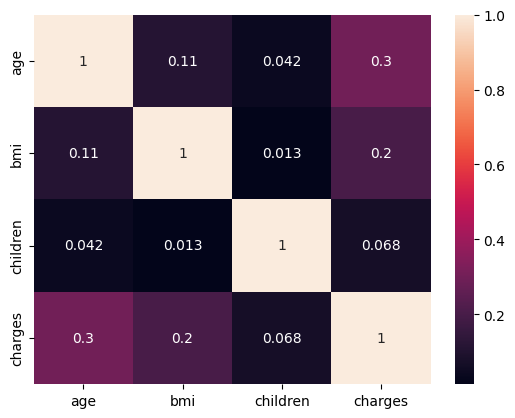

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot = True)
plt.show()

In [ ]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


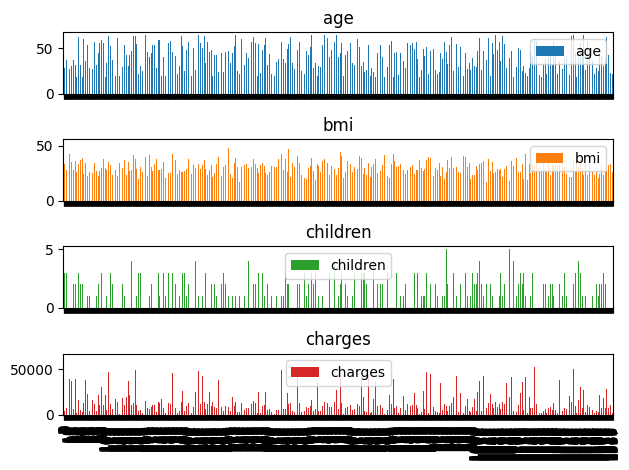

In [ ]:
df.plot.bar(subplots=True)
plt.tight_layout()
plt.show()

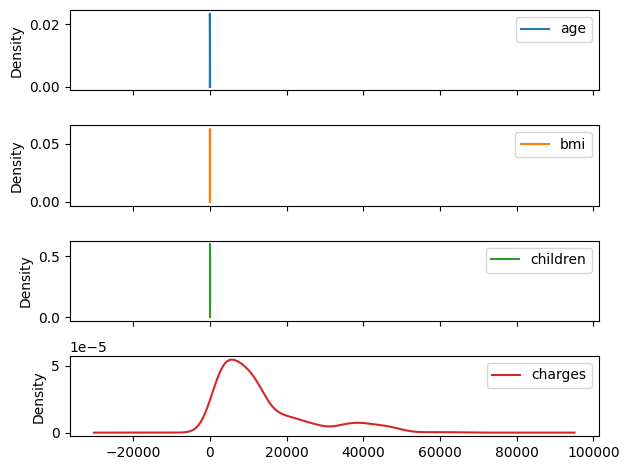

In [ ]:
df.plot.kde(subplots=True)
plt.tight_layout()
plt.show()

1.Features: 7 features

2.Problem: Regression. Beacuse continuous numerical values

3.Data points: 1338

4.Null values: No null values

5.Features types: Age, bmi, children, charges numerical and sex, smoker, region categorical

6.Encoding: Yes. sex, smoker and region must be encoded. Because Linear regression, Logistic regression require numerical input

7.Correlation: Age and charges has correlation 0.3 which is most in this data set

8.EDA: Charges column right skewed

##Answer:





#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder

In [ ]:
X = df.drop(columns=['charges'])
y = df['charges']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features_without_sex_and_smoker = ['region']
categorical_features_with_sex_and_smoker = ['sex', 'smoker']

numerical_features_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categorical_features_one_hot_encoding = Pipeline(
    steps=[
        ('one_hot_encoding', OneHotEncoder(handle_unknown="ignore"))
    ]
)

categorical_features_ordinal_encoding = Pipeline(
    steps=[
        ('ordinal_encoding', OrdinalEncoder())
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ("num",numerical_features_transformer,numerical_features),
        ("cat_one_hot",categorical_features_one_hot_encoding,categorical_features_without_sex_and_smoker),
        ("cat_ordinal",categorical_features_ordinal_encoding,categorical_features_with_sex_and_smoker)
    ]
)

I have used standard scaler for numerical columns. Because larger value ranges can have a larger influence about distance calculations. Scaling helps all features contribute equally to the model.

I used one hot encoding on region because it is a categorical column with very few different values.

I have used ordinal encoding on sex and smoker because they are in binary

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



I am going to keep all features. All are important and all features are logically connected with charges. age and bmi column has good correlation with charges. while children has less correlation with charges but it's not useless. And for categorical features I have done one hot encoding and label encoding

In [ ]:
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr_pipeline = Pipeline(
    steps = [
        ("preprocessor",preprocessor),
        ("model", LinearRegression())
    ]
)

In [ ]:
char_median = df['charges'].median()
y_cf = (df['charges'] >= char_median).astype(int)

X_train_cf, X_test_cf , y_train_cf, y_test_cf = train_test_split(X, y_cf, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(
    steps = [
        ("preprocessor",preprocessor),
        ("model", LogisticRegression(random_state=42))
    ]
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model',KNeighborsClassifier(n_neighbors=37,metric='minkowski',p=2))
    ]
    )

# 5. Model Training (5 marks)

Train those 2 models



In [ ]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat_one_hot',
                                                  Pipeline(steps=[('one_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['region']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('ordinal_encoding',
                                                                   OrdinalEncoder())]),
                                                  ['sex', 'smoker'])])),
                ('model', LinearRegression())])

In [ ]:
log_reg_pipeline.fit(X_train_cf, y_train_cf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat_one_hot',
                                                  Pipeline(steps=[('one_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['region']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('ordinal_encoding',
                                                                   OrdinalEncoder())]),
                                                  ['sex', 'smoker'])])),
                ('model', LogisticRegression(random_state=42))])

In [ ]:
knn_model_pipeline.fit(X_train_cf, y_train_cf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat_one_hot',
                                                  Pipeline(steps=[('one_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['region']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('ordinal_encoding',
                                                                   OrdinalEncoder())]),
                                                  ['sex', 'smoker'])])),
                ('model', KNeighborsClassifier(n_neighbors=37))])

## Answer:

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [ ]:
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, precision_score, recall_score, confusion_matrix, mean_absolute_error

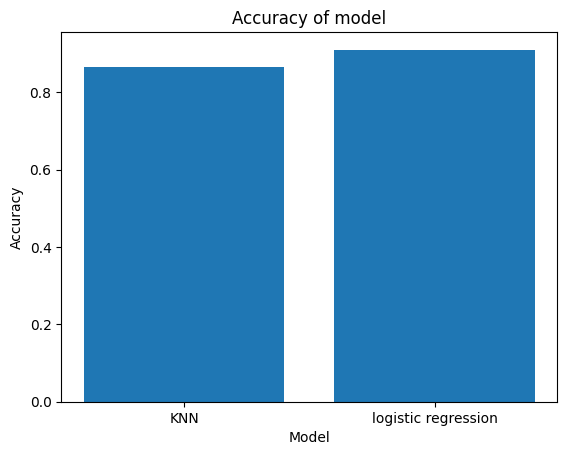

In [ ]:
knn_predict = knn_model_pipeline.predict(X_test_cf)
logistic_predict = log_reg_pipeline.predict(X_test_cf)

knn_accuracy = accuracy_score(y_test_cf, knn_predict)
logistic_accuracy = accuracy_score(y_test_cf, logistic_predict)

model = ['KNN', 'logistic regression']
accuracy = [knn_accuracy, logistic_accuracy]

plt.bar(model, accuracy)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy of model')
plt.show()

In [ ]:
knn_precision = precision_score(y_test_cf, knn_predict)
logistic_precision = precision_score(y_test_cf, logistic_predict)

knn_recall = recall_score(y_test_cf, knn_predict)
logistic_recall = recall_score(y_test_cf, logistic_predict)

data_frame = {
    'Model':['KNN', 'Logistic_Regression'],
    'Precision':[knn_precision,logistic_precision],
    'Recall':[knn_recall,logistic_recall]
}

df = pd.DataFrame(data_frame)
print(df)

                 Model  Precision    Recall
0                  KNN   0.890909  0.803279
1  Logistic_Regression   0.882812  0.926230


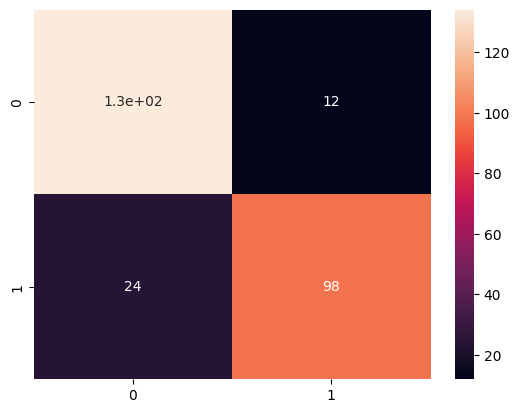

In [ ]:
con_matrix = confusion_matrix(y_test_cf, knn_predict)
sns.heatmap(con_matrix, annot=True)
plt.show()

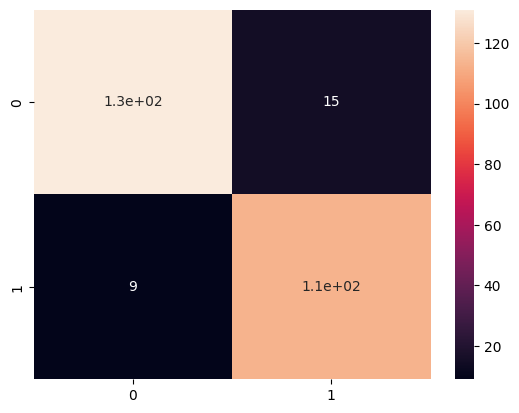

In [ ]:
con_matrix = confusion_matrix(y_test_cf, logistic_predict)
sns.heatmap(con_matrix, annot=True)
plt.show()

In [ ]:
linear_pred = lr_pipeline.predict(X_test)
r2 = r2_score(y_test, linear_pred)
mae = mean_absolute_error(y_test, linear_pred)
mse = mean_squared_error(y_test, linear_pred)

print(f'R2 score {r2}')
print(f'MAE {mae}')
print(f'MSE {mse}')

R2 score 0.7835929767120724
MAE 4181.194473753647
MSE 33596915.85136145


Logistic regression perform better than KNN. KNN has better precision but Logistic regression higher accuracy and higher recall prove that it is more effective to indentify positive case

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
X_scaled = preprocessor.fit_transform(X)

dbscan = DBSCAN(eps = 0.3 , min_samples =3 )

dbscan.fit(X_scaled)

label_dbscan= dbscan.labels_

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
score = silhouette_score(X_scaled, label_dbscan)
print(score)

-0.21359324531742657


Silhouette socre is -0.21, which means bad. It means that data points placed in to wrong cluster.

On the other hand the supervised model I have used before for classification accuracy and precision and recall is good. And for regression task r2 score good.

So supervised is better for this data set

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

For me the hardest topic was support vector machine. It looks harder for me because of hard margin and soft margin.We can use it for face and image recoginition. It use maximum margin between data groups and make accuracy better on unseen data.It's highly effective and memory efficient.

The easiest topic was Linear regression. We can use it for house price prediction, demand and sales forecasting. It runs smoothly in massive dataset